<b><h1><center>RETAIL SALES OPTIMIZATION</center></h1></b>

<hr>

<b><h1>Import Libraries</h1></b>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


<b><h1>Load Dataset</h1></b>

In [2]:
df=pd.read_csv("../Data/raw_data.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150.0
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000.0
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30.0
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100.0


In [4]:
df.shape

(1012, 9)

<b><h1>Data Cleaning</h1></b>

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    1012 non-null   int64  
 1   Date              1012 non-null   str    
 2   Customer ID       1012 non-null   str    
 3   Gender            1005 non-null   str    
 4   Age               1012 non-null   int64  
 5   Product Category  1009 non-null   str    
 6   Quantity          1012 non-null   int64  
 7   Price per Unit    1012 non-null   int64  
 8   Total Amount      1009 non-null   float64
dtypes: float64(1), int64(4), str(4)
memory usage: 101.5 KB


In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1012.000000,1012.000000,1012.000000,1012.000000,1009.000000
mean,495.270751,41.359684,2.518775,179.644269,454.311199
std,291.045885,13.718776,1.133364,189.583259,559.962350
min,1.000000,18.000000,1.000000,25.000000,25.000000
25%,241.750000,29.000000,1.000000,30.000000,60.000000
50%,494.500000,42.000000,3.000000,50.000000,120.000000
75%,747.250000,53.000000,4.000000,300.000000,900.000000
max,1000.000000,64.000000,4.000000,500.000000,2000.000000


In [7]:
df["Date"]=pd.to_datetime(df["Date"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1012 non-null   int64         
 1   Date              1012 non-null   datetime64[us]
 2   Customer ID       1012 non-null   str           
 3   Gender            1005 non-null   str           
 4   Age               1012 non-null   int64         
 5   Product Category  1009 non-null   str           
 6   Quantity          1012 non-null   int64         
 7   Price per Unit    1012 non-null   int64         
 8   Total Amount      1009 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(4), str(3)
memory usage: 91.7 KB


In [9]:
df.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              7
Age                 0
Product Category    3
Quantity            0
Price per Unit      0
Total Amount        3
dtype: int64

In [10]:
df["Product Category"]=df["Product Category"].fillna(df["Product Category"].mode()[0])
df["Gender"]=df["Gender"].fillna(df["Gender"].mode()[0])

In [11]:
df.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        3
dtype: int64

In [12]:
df.drop(columns="Total Amount", inplace=True)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1012 non-null   int64         
 1   Date              1012 non-null   datetime64[us]
 2   Customer ID       1012 non-null   str           
 3   Gender            1012 non-null   str           
 4   Age               1012 non-null   int64         
 5   Product Category  1012 non-null   str           
 6   Quantity          1012 non-null   int64         
 7   Price per Unit    1012 non-null   int64         
dtypes: datetime64[us](1), int64(4), str(3)
memory usage: 83.6 KB


In [14]:
df.duplicated().sum()

np.int64(12)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

<b><h1>Feature Engineering</h1></b>

In [17]:
df["Age Category"]=pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["Teen", "Young", "Adult", "Middle Age", "Senior"]
)

df["Month"]=df["Date"].dt.month_name()
months_order=["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df["Month"]=pd.Categorical(df["Month"], categories=months_order, ordered=True)
df["Year"]=df["Date"].dt.year
df["Total Amount"]=df["Price per Unit"]*df["Quantity"]

In [18]:
df[["Month", "Year", "Age Category", "Total Amount"]]

,Month,Year,Age Category,Total Amount
0,November,2023,Adult,150
1,February,2023,Young,1000
2,January,2023,Middle Age,30
3,May,2023,Adult,500
4,May,2023,Young,100
...,...,...,...,...
1007,May,2023,Senior,50
1008,November,2023,Middle Age,90
1009,October,2023,Young,100
1010,December,2023,Adult,150


In [19]:
df["Month"].unique()

['November', 'February', 'January', 'May', 'April', ..., 'October', 'August', 'September', 'June', 'July']
Length: 12
Categories (12, str): ['January' < 'February' < 'March' < 'April' ... 'September' < 'October' < 'November' < 'December']

In [20]:

df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 0 to 1011
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Age Category      1000 non-null   category      
 9   Month             1000 non-null   category      
 10  Year              1000 non-null   int32         
 11  Total Amount      1000 non-null   int64         
dtypes: category(2), datetime64[us](1), int32(1), int64(5), str(3)
memory usage: 105.0 KB


In [21]:
df.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Age Category        0
Month               0
Year                0
Total Amount        0
dtype: int64

<b><h1>Exploratory Data Analysis (EDA)</h1></b>

In [22]:
df.columns


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Age Category',
       'Month', 'Year', 'Total Amount'],
      dtype='str')

In [23]:
df.shape

(1000, 12)

In [24]:
df["Year"].unique()

array([2023, 2024], dtype=int32)

<b><h3>Which Category Produce Highest Total Sales Amount</h3></b>

In [25]:
cat_hig_sale=df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
cat_hig_sale

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

<b><h3>Which Category Produce Highest Sales Quantity</h3></b>

In [26]:
cat_hig_quan=df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)
cat_hig_quan

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

<b><h3>Which Gender Buying Rate is Higher</h3></b>

In [27]:
gen_sale=df.groupby("Gender")["Total Amount"].sum().sort_values(ascending=False)
gen_sale

Gender
Female    233740
Male      222260
Name: Total Amount, dtype: int64

<b><h3>Which Year Produce Highest Sales</h3></b>

In [28]:
year_sale=df.groupby("Year")["Total Amount"].sum().sort_values(ascending=False)
year_sale

Year
2023    454470
2024      1530
Name: Total Amount, dtype: int64

<b><h3>Which Month of Both 2023 & 2024 Year Produce Highest Sales</h3></b>

In [29]:
month_sale=df.groupby("Month")["Total Amount"].sum()
month_sale

Month
January      36980
February     44060
March        28990
April        33870
May          53150
June         36715
July         35465
August       36960
September    23620
October      46580
November     34920
December     44690
Name: Total Amount, dtype: int64

<b><h3>Which Month of 2023 Year Produce Highest Sales</h3></b>

In [30]:
first_year_sale=df[df["Year"]==2023]
first_year_sale["Year"].unique()


array([2023], dtype=int32)

In [31]:
firstyear_month_sale=first_year_sale.groupby("Month")["Total Amount"].sum().sort_values(ascending=False)
firstyear_month_sale

Month
May          53150
October      46580
December     44690
February     44060
August       36960
June         36715
July         35465
January      35450
November     34920
April        33870
March        28990
September    23620
Name: Total Amount, dtype: int64

<b><h3>Which Month of 2024 Year Produce Highest Sales</h3></b>

In [32]:
second_year_sale=df[df["Year"]==2024]
second_year_sale["Year"].unique()

array([2024], dtype=int32)

In [33]:
secondyear_month_sale=second_year_sale.groupby("Month")["Total Amount"].sum().sort_values(ascending=False)
secondyear_month_sale

Month
January    1530
Name: Total Amount, dtype: int64

<b><h3>Which Age Category Buying Rate is Highest</h3></b>

In [34]:
age_sale=df.groupby("Age Category")["Total Amount"].sum().sort_values(ascending=False)
age_sale

Age Category
Middle Age    147875
Adult         141955
Young         121730
Senior         33225
Teen           11215
Name: Total Amount, dtype: int64

<b><h1>Visualization</h1></b>

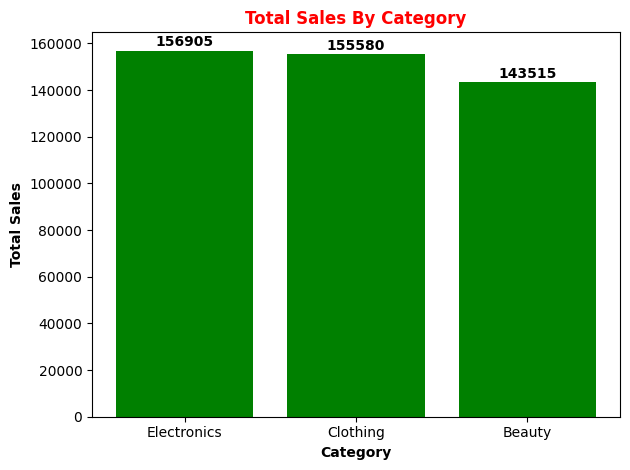

In [35]:
plt.bar(cat_hig_sale.index, cat_hig_sale.values, color="green")
for i,value in enumerate(cat_hig_sale):
    plt.annotate(text=(str(value)), xy=(i, value), xytext=(0,3), textcoords="offset points", ha="center", fontweight="bold")
plt.xlabel("Category", fontweight="bold")
plt.ylabel("Total Sales", fontweight="bold")
plt.title("Total Sales By Category", fontweight="bold", color="red")
plt.tight_layout()
plt.savefig("../Visual/Total Sales By Category", dpi=300, bbox_inches="tight")
plt.show()

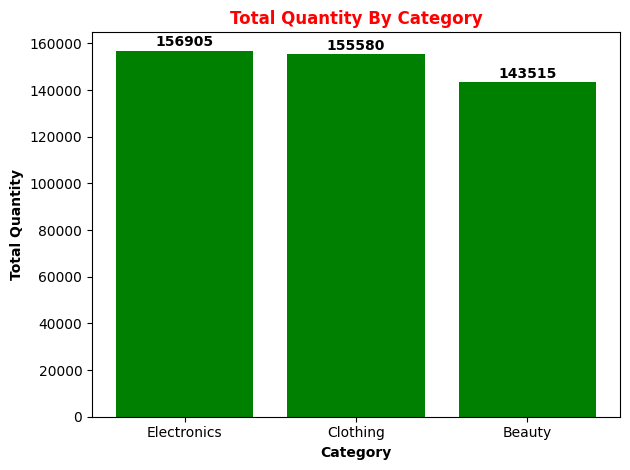

In [36]:
plt.bar(cat_hig_sale.index, cat_hig_sale.values, color="green")
for i,value in enumerate(cat_hig_sale):
    plt.annotate(text=(str(value)), xy=(i, value), xytext=(0, 3), textcoords="offset points", ha="center", fontweight="bold")
plt.xlabel("Category", fontweight="bold")
plt.ylabel("Total Quantity", fontweight="bold")
plt.title("Total Quantity By Category", fontweight="bold", color="red")
plt.tight_layout()
plt.savefig("../Visual/Total Quantity By Category", dpi=300, bbox_inches="tight")
plt.show()

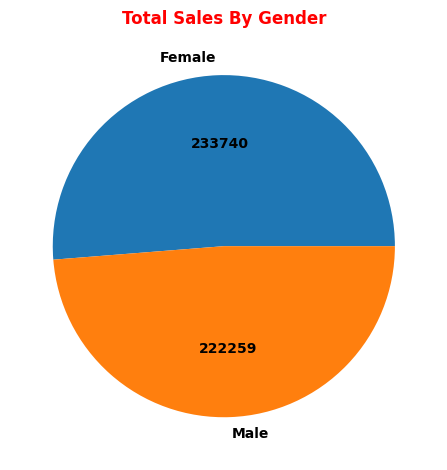

In [37]:
def value(pct):
    sums=sum(gen_sale.values)
    total=int(pct*sums/100)
    return total

plt.pie(gen_sale.values, labels=gen_sale.index, autopct=value, textprops={"fontweight":"bold"})
plt.title("Total Sales By Gender", fontweight="bold", color="red")
plt.tight_layout()
plt.savefig("../Visual/Total Sales By Gender", dpi=300, bbox_inches="tight")
plt.show()


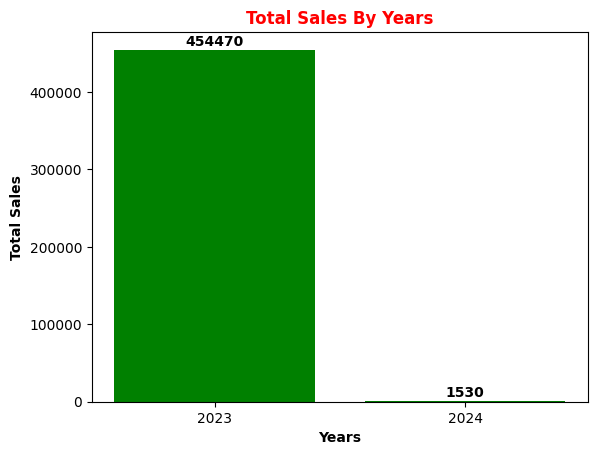

In [38]:
plt.bar(year_sale.index, year_sale.values, color="green")
plt.xticks(year_sale.index)
for i,value in enumerate(year_sale):
    plt.annotate(text=(str(value)), xy=(year_sale.index[i], value), xytext=(0, 3), textcoords="offset points", ha="center", fontweight="bold")
plt.title("Total Sales By Years", fontweight="bold", color="red")
plt.xlabel("Years", fontweight="bold")
plt.ylabel("Total Sales", fontweight="bold")
plt.savefig("../visual/Total Sales By Years", dpi=300, bbox_inches="tight")
plt.show()

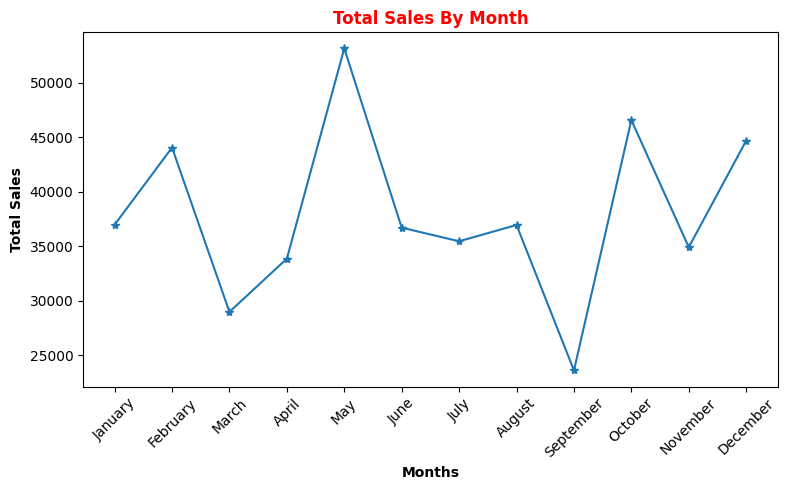

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(month_sale.index, month_sale.values, marker="*")
plt.xlabel("Months", fontweight="bold")
plt.ylabel("Total Sales", fontweight="bold")
plt.title("Total Sales By Month", fontweight="bold", color="red")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visual/Total Sales By Month", dpi=300, bbox_inches="tight")
plt.show()

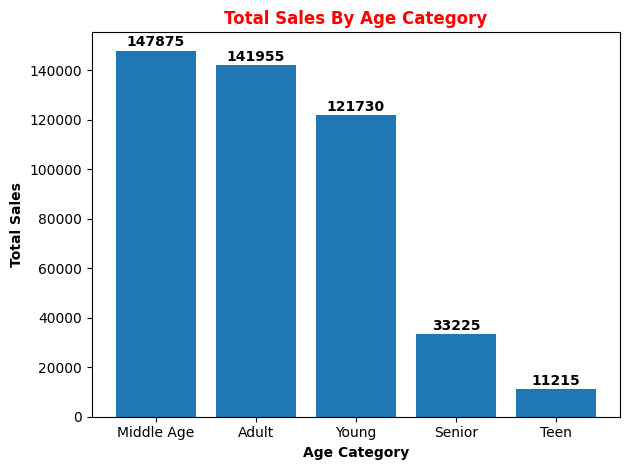

In [40]:
plt.bar(age_sale.index, age_sale.values)
for i, value in enumerate(age_sale):
    plt.annotate(text=(str(value)), xy=(age_sale.index[i], value), xytext=(0, 3), textcoords="offset points", ha="center", fontweight="bold")
plt.xlabel("Age Category", fontweight="bold")
plt.ylabel("Total Sales", fontweight="bold")
plt.title("Total Sales By Age Category", fontweight="bold", color="red")
plt.tight_layout()
plt.savefig("../visual/Total Sales By Age Category", dpi=300, bbox_inches="tight")
plt.show()

<b><h1>Save Dataset</h1></b>

In [41]:
df.to_csv("../Data/clean_data.csv", index=False)

<b><h1>Load to Database</h1></b>

In [42]:
from sqlalchemy import create_engine

engine = create_engine("mysql+pymysql://root:@localhost:3306/retail_sales_optimization")

df.to_sql(
    name="sales_data",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data successfully store in database")

Data successfully store in database


<b><h1><center>THE END</center></h1></b>

<hr>